Reading existing


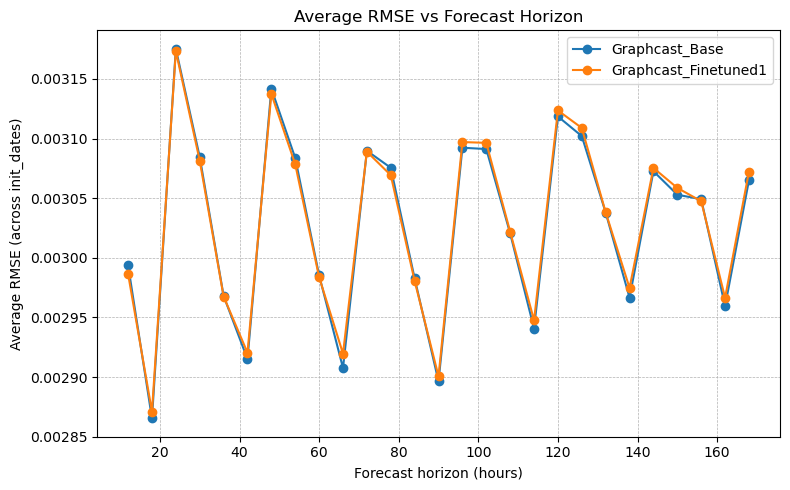

Plotted your data.


,model,forecast_horizon_hours,rmse_mean
0,Graphcast_Base,12.0,0.002994
1,Graphcast_Base,18.0,0.002865
2,Graphcast_Base,24.0,0.003175
3,Graphcast_Base,30.0,0.003085
4,Graphcast_Base,36.0,0.002968
5,Graphcast_Base,42.0,0.002915
6,Graphcast_Base,48.0,0.003142
7,Graphcast_Base,54.0,0.003084
8,Graphcast_Base,60.0,0.002985
9,Graphcast_Base,66.0,0.002908


In [4]:
# Safe, self-contained version:
# - If `df` isn't in memory and CSV_PATH doesn't exist, it will create a small demo dataset so the cell runs.
# - Otherwise behaves the same.
#
# Set CSV_PATH to your file and re-run if you want to load your data.

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------- configure ---------------
CSV_PATH = "6h_finetuned.csv"  # change this if needed
MODELS_TO_PLOT = ('Graphcast_Base','Graphcast_Finetuned1')     # e.g., ("Graphcast_Base", "Graphcast_Finetuned1")

# --------------- load data ---------------
use_demo = False
try:
    df  # type: ignore[name-defined]
    _df = df.copy()
except NameError:
    if Path(CSV_PATH).exists():
        _df = pd.read_csv(CSV_PATH)
        print("Reading existing")
    else:
        use_demo = True
        _df = pd.DataFrame({
            "model": ["Graphcast_Base"] * 4 + ["Graphcast_Finetuned1"] * 4,
            "init_date": ["2014-08-01"] * 8,
            "forecast_horizon_hours": [6.0, 12.0, 18.0, 24.0] * 2,
            "rmse": [0.005, 0.0049, 0.0052, 0.0054, 0.0047, 0.0046, 0.0048, 0.0051],
        })

# --------------- clean types ---------------
_df["model"] = _df["model"].astype(str)
if "init_date" in _df.columns:
    _df["init_date"] = pd.to_datetime(_df["init_date"], errors="coerce")
_df["forecast_horizon_hours"] = pd.to_numeric(_df["forecast_horizon_hours"], errors="coerce")
_df["rmse"] = pd.to_numeric(_df["rmse"], errors="coerce")
_df = _df.dropna(subset=["model", "forecast_horizon_hours", "rmse"]).copy()

# --------------- aggregate: mean over init_dates ---------------
avg_df = (
    _df.groupby(["model", "forecast_horizon_hours"], as_index=False)["rmse"]
       .mean()
       .rename(columns={"rmse": "rmse_mean"})
)

# --------------- select models ---------------
all_models = tuple(sorted(avg_df["model"].unique()))
if MODELS_TO_PLOT is None:
    MODELS_TO_PLOT = all_models  # default to plotting all models

# --------------- plot ---------------
plt.figure(figsize=(8, 5))
any_plotted = False
for m in MODELS_TO_PLOT:
    d = avg_df.loc[avg_df["model"] == m].sort_values("forecast_horizon_hours")
    if d.empty:
        continue
    plt.plot(
        d["forecast_horizon_hours"].values,
        d["rmse_mean"].values,
        marker="o",
        label=m,
    )
    any_plotted = True

plt.xlabel("Forecast horizon (hours)")
plt.ylabel("Average RMSE (across init_dates)")
plt.title("Average RMSE vs Forecast Horizon")
if any_plotted:
    plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# --------------- info ---------------
if use_demo:
    print("Note: CSV not found and no `df` in memory. Plotted a small demo dataset instead.")
else:
    print("Plotted your data.")
    
avg_df.sort_values(["model", "forecast_horizon_hours"]).head(20)
